# Mini App Performance Analysis

I kinda messed up, the force upload should be run for the non-cmi version....im kinda retarded

In [14]:
import os
import re
import pandas as pd
from pathlib import Path

# --- Configuration ---
LOGS_DIR = Path('logs')
MIN_JOB_ID = 1237937

def build_run_name(exp_path, content):
    """Build a descriptive label: CMI_SMARTSIM_FORCE, CMI_PHYDLL_CPP, etc."""
    is_cmi = '_cpp_interface_' in exp_path

    if is_cmi:
        m = re.search(r'_cpp_interface_([^_]+)_', exp_path)
        provider = m.group(1).upper() if m else 'UNKNOWN'
        name = f'CMI_{provider}'

        if not is_cmi and 'force_terrain_upload' in exp_path and 'no_force_terrain_upload' not in exp_path:
            name += '_FORCE'

        if provider == 'PHYDLL':
            if 'phydll_dl_client.py' in content:
                name += '_PY'
            elif 'phydll_dl_runtime' in content or 'dl_clients/build/phydll_dl_client' in content:
                name += '_CPP'
        return name
    else:
        return 'SMARTSIM'

def parse_log_file(file_path):
    try:
        content = file_path.read_text(encoding='utf-8', errors='replace')
    except Exception:
        return None

    match = re.search(r'mini_app_output_(\d+)\.txt', file_path.name)
    if not match:
        return None
    job_id = int(match.group(1))

    path_match = re.search(r'Timing and parameters saved to: (.+)/timing_and_parameters\.txt', content)
    if not path_match:
        return None

    exp_path = path_match.group(1)

    solving_time = None
    solving_match = re.search(r'Solving time: (\d+) seconds', content)
    if solving_match:
        solving_time = int(solving_match.group(1))

    def get_gib(pattern, text):
        m = re.search(pattern, text)
        return float(m.group(1)) if m else None

    ml_input = get_gib(r'ml_input:\s+([0-9.]+) GiB', content)
    ml_output = get_gib(r'ml_output:\s+([0-9.]+) GiB', content)
    ml_preload = get_gib(r'ml_preload:([0-9.]+) GiB', content)

    ib0_rx = None
    ib0_tx = None
    ib0_match = re.search(r'ib0: rx ([0-9.]+) GiB.*?, tx ([0-9.]+) GiB', content)
    if ib0_match:
        ib0_rx = float(ib0_match.group(1))
        ib0_tx = float(ib0_match.group(2))

    lo_rx = None
    lo_tx = None
    lo_match = re.search(r'lo: rx ([0-9.]+) GiB.*?, tx ([0-9.]+) GiB', content)
    if lo_match:
        lo_rx = float(lo_match.group(1))
        lo_tx = float(lo_match.group(2))

    run_name = build_run_name(exp_path, content)
    
    # if run_name already exists in data, append a suffix to make it unique
    existing_names = {row['RunName'] for row in data}
    if run_name in existing_names:
        suffix = 1
        new_run_name = f"{run_name}_{suffix}"
        while new_run_name in existing_names:
            suffix += 1
            new_run_name = f"{run_name}_{suffix}"
        run_name = new_run_name

    return {
        'JobID': job_id,
        'RunName': run_name,
        'SolvingTime_s': solving_time,
        'ML_Input_GiB': ml_input,
        'ML_Output_GiB': ml_output,
        'ML_Preload_GiB': ml_preload,
        'IB0_RX_GiB': ib0_rx,
        'IB0_TX_GiB': ib0_tx,
        'LO_RX_GiB': lo_rx,
        'LO_TX_GiB': lo_tx,
    }

data = []
for f in LOGS_DIR.glob('mini_app_output_*.txt'):
    job_id_match = re.search(r'mini_app_output_(\d+)\.txt', f.name)
    if job_id_match:
        jid = int(job_id_match.group(1))
        if jid >= MIN_JOB_ID:
            row = parse_log_file(f)
            if row:
                data.append(row)

if data:
    df = pd.DataFrame(data)
    df = df.sort_values('JobID').reset_index(drop=True)
else:
    df = pd.DataFrame()

df

,JobID,RunName,SolvingTime_s,ML_Input_GiB,ML_Output_GiB,ML_Preload_GiB,IB0_RX_GiB,IB0_TX_GiB,LO_RX_GiB,LO_TX_GiB
0,1237937,SMARTSIM,3217,6.26,0.7,1.25,0.76,9.40,0.0,0.0
1,1237941,CMI_SMARTSIM_1,3208,12.51,0.7,0.00,0.75,16.17,0.0,0.0
2,1237944,CMI_SMARTSIM,3210,12.51,0.7,0.00,0.75,16.17,0.0,0.0
3,1237947,CMI_AIX,3184,12.51,0.7,0.00,0.01,0.01,0.0,0.0
4,1295399,CMI_PHYDLL_CPP,3333,12.51,0.7,0.00,0.05,0.04,0.0,0.0
5,1295403,CMI_PHYDLL_PY,3397,12.51,0.7,0.00,0.05,0.04,0.0,0.0


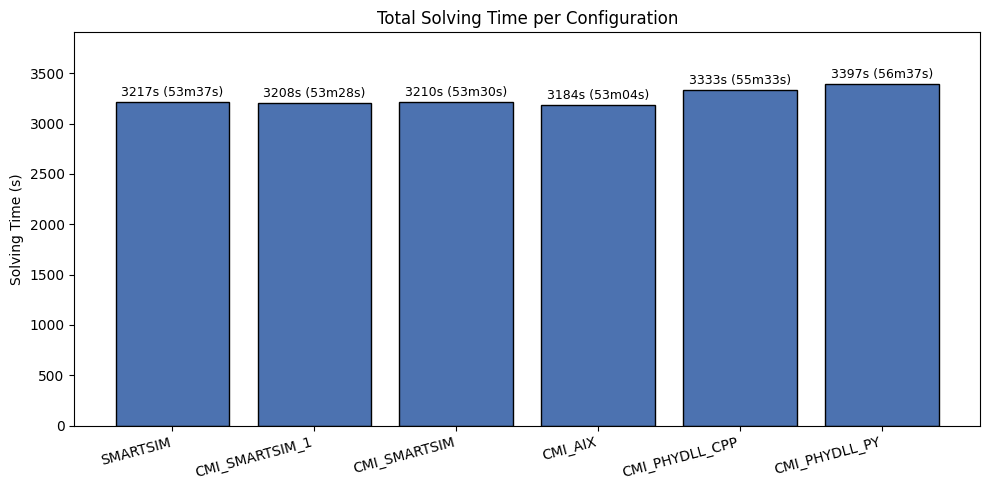

In [15]:
import matplotlib.pyplot as plt
import numpy as np

valid = df[df['SolvingTime_s'] > 0].copy()
if not valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(valid['RunName'], valid['SolvingTime_s'], color='#4C72B0', edgecolor='black')
    for bar, val in zip(bars, valid['SolvingTime_s']):
        h = int(val // 3600)
        m = int((val % 3600) // 60)
        s = int(val % 60)
        label = f"{val}s ({h}h{m:02d}m{s:02d}s)" if h > 0 else f"{val}s ({m}m{s:02d}s)"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                label, ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Solving Time (s)')
    ax.set_title('Total Solving Time per Configuration')
    ax.set_ylim(0, valid['SolvingTime_s'].max() * 1.15)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No valid solving time data.')

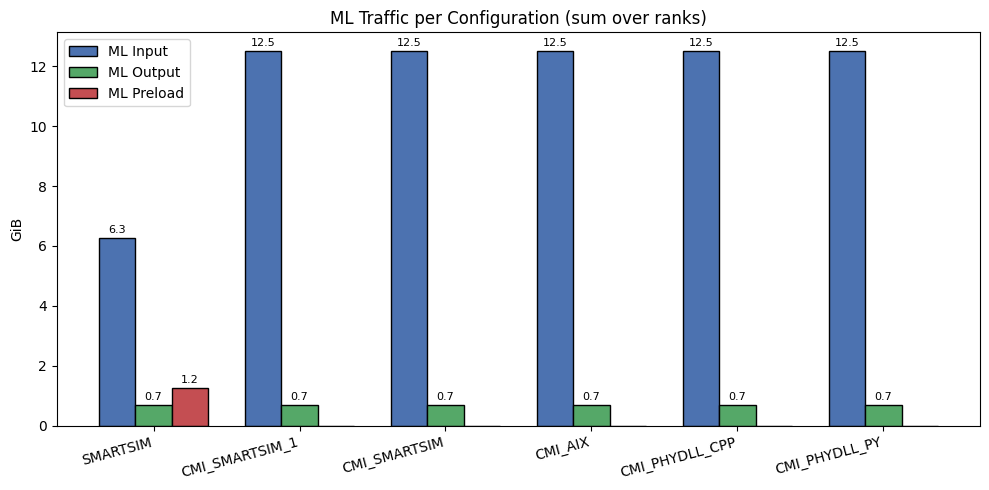

In [16]:
traffic = df.dropna(subset=['ML_Input_GiB', 'ML_Output_GiB', 'ML_Preload_GiB']).copy()
if not traffic.empty:
    x = np.arange(len(traffic))
    w = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - w, traffic['ML_Input_GiB'], w, label='ML Input', color='#4C72B0', edgecolor='black')
    b2 = ax.bar(x, traffic['ML_Output_GiB'], w, label='ML Output', color='#55A868', edgecolor='black')
    b3 = ax.bar(x + w, traffic['ML_Preload_GiB'], w, label='ML Preload', color='#C44E52', edgecolor='black')
    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
                        f'{h:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('GiB')
    ax.set_title('ML Traffic per Configuration (sum over ranks)')
    ax.set_xticks(x)
    ax.set_xticklabels(traffic['RunName'], rotation=15, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No valid ML traffic data.')

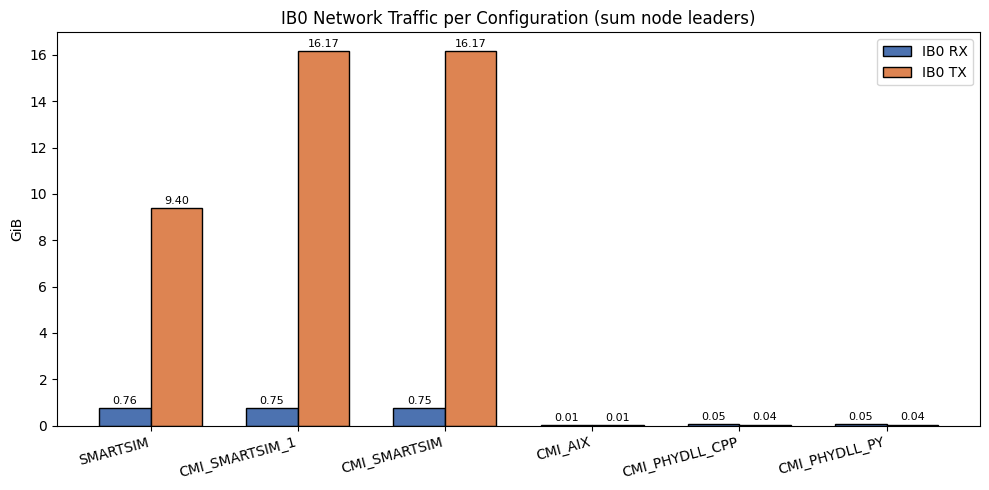

In [17]:
net = df.dropna(subset=['IB0_RX_GiB', 'IB0_TX_GiB']).copy()
if not net.empty:
    x = np.arange(len(net))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - w / 2, net['IB0_RX_GiB'], w, label='IB0 RX', color='#4C72B0', edgecolor='black')
    b2 = ax.bar(x + w / 2, net['IB0_TX_GiB'], w, label='IB0 TX', color='#DD8452', edgecolor='black')
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylabel('GiB')
    ax.set_title('IB0 Network Traffic per Configuration (sum node leaders)')
    ax.set_xticks(x)
    ax.set_xticklabels(net['RunName'], rotation=15, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No valid IB0 network data.')